In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, ttest_ind, f_oneway
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Visualization settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Load dataset
df = pd.read_csv("business_data.csv")

# Preview data
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Dataset Shape: (100, 7)

Column Names:
 Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Missing Values:
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Data Types:
 Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object


In [5]:
mean_sales = df["Total_Sales"].mean()
median_sales = df["Total_Sales"].median()
std_sales = df["Total_Sales"].std()
variance_sales = df["Total_Sales"].var()

print("Mean Total_Sales:", mean_sales)
print("Median Total_Sales:", median_sales)
print("Standard Deviation:", std_sales)
print("Variance:", variance_sales)

Mean Total_Sales: 123650.48
Median Total_Sales: 97955.5
Standard Deviation: 100161.08527499212
Variance: 10032243003.464243


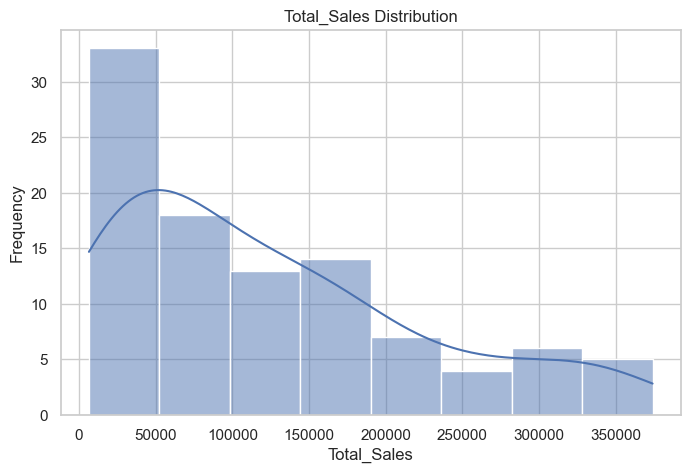

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Sales"], kde=True)
plt.title("Total_Sales Distribution")
plt.xlabel("Total_Sales")
plt.ylabel("Frequency")
plt.show()

In [7]:
stat, p_value = shapiro(df["Total_Sales"])

print("Shapiro-Wilk Test")
print("Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Data is normally distributed")
else:
    print("Data is NOT normally distributed")

Shapiro-Wilk Test
Statistic: 0.8989262036779536
p-value: 1.259076720571478e-06
Data is NOT normally distributed


In [8]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Quantity,Price,Total_Sales
Quantity,1.000000,0.008014,0.688107
Price,0.008014,1.000000,0.646131
Total_Sales,0.688107,0.646131,1.000000


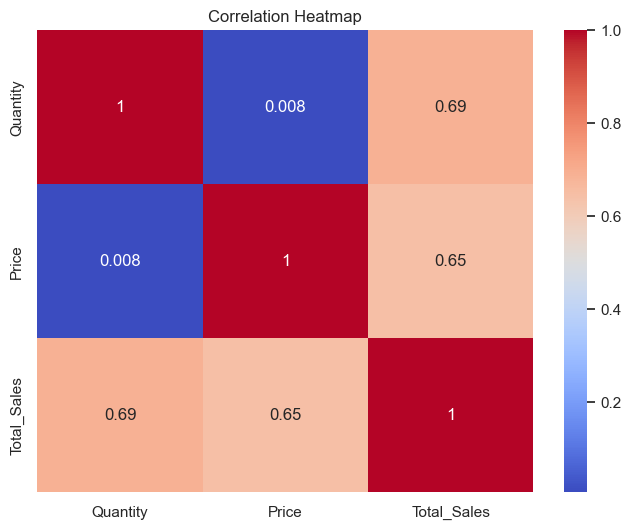

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
corr_value, corr_p = stats.pearsonr(df["Quantity"], df["Total_Sales"])

print("Pearson Correlation:", corr_value)
print("p-value:", corr_p)

Pearson Correlation: 0.6881074758580695
p-value: 2.5805137996277936e-15


In [12]:
df.columns

Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

In [13]:
# Example: Comparing two regions
region1 = df[df["Region"] == df["Region"].unique()[0]]["Total_Sales"]
region2 = df[df["Region"] == df["Region"].unique()[1]]["Total_Sales"]

t_stat, p_val = ttest_ind(region1, region2)

print("T-Test Results")
print("t-statistic:", t_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Significant difference between regions")
else:
    print("No significant difference")

T-Test Results
t-statistic: -0.35710677600784724
p-value: 0.7226811638407535
No significant difference


In [14]:
mean = np.mean(df["Total_Sales"])
sem = stats.sem(df["Total_Sales"])

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(df["Total_Sales"])-1,
    loc=mean,
    scale=sem
)

margin_of_error = sem * stats.t.ppf((1 + 0.95) / 2., len(df["Total_Sales"])-1)

print("Mean Total_Sales:", mean)
print("95% Confidence Interval:", confidence_interval)
print("Margin of Error:", margin_of_error)

Mean Total_Sales: 123650.48
95% Confidence Interval: (np.float64(103776.34767158539), np.float64(143524.6123284146))
Margin of Error: 19874.132328414606


In [15]:
X = df[["Quantity"]]
y = df["Total_Sales"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R-squared:", r2)

Intercept: -3638.741480185796
Coefficient: 26629.544242716693
R-squared: 0.47349189833176386


In [17]:
print("STATISTICAL ANALYSIS REPORT")
print("----------------------------------")
print(f"Average Sales: ${mean:,.2f} ± ${margin_of_error:,.2f} (95% CI)")
print(f"Correlation (Sales-Marketing): {corr_value:.2f}")
print(f"Regression R-Squared: {r2:.2f}")
print(f"Marketing p-value: {corr_p:.4f}")

if corr_p < 0.05:
    print("Marketing significantly affects Sales ✓ SIGNIFICANT")
else:
    print("Marketing does NOT significantly affect Sales")

STATISTICAL ANALYSIS REPORT
----------------------------------
Average Sales: $123,650.48 ± $19,874.13 (95% CI)
Correlation (Sales-Marketing): 0.69
Regression R-Squared: 0.47
Marketing p-value: 0.0000
Marketing significantly affects Sales ✓ SIGNIFICANT
